# Replicating the DeepSeek R1 "Aha Moment"

This notebook contains the **complete solution** for replicating the DeepSeek R1 "Aha Moment"
using GRPO (Group Relative Policy Optimization) on the Countdown Game task.

**Reference:** [Build Your Own Mini DeepSeek R1](https://www.philschmid.de/mini-deepseek-r1) by Philipp Schmid

> **Note:** This version is configured for **single-GPU testing** (QLoRA, 2 generations/prompt).


## Cell 1: Install Dependencies

In [ ]:
# Cell 1: Install Dependencies
!pip install "torch==2.5.1" tensorboard --index-url https://download.pytorch.org/whl/cu121
!pip install flash-attn --no-build-isolation
!pip install "transformers==4.48.1" "datasets==3.1.0" "accelerate==1.3.0"
!pip install "trl==0.14.0" "deepspeed==0.15.4" "vllm==0.7.0"
!pip install "bitsandbytes>=0.45.0" "peft>=0.14.0"

Looking in indexes: https://download.pytorch.org/whl/cu121

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
import os

BASE = "/workspace"

os.environ["HF_HOME"] = f"{BASE}/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = f"{BASE}/hf_cache"
os.environ["TORCH_HOME"] = f"{BASE}/torch_cache"
os.environ["XDG_CACHE_HOME"] = f"{BASE}/cache"

## Cell 2: Authenticate with Hugging Face

In [ ]:
# Cell 2: Authenticate with Hugging Face
from huggingface_hub import login

login(token="hf_YOUR_TOKEN_HERE", add_to_git_credential=True)
# Replace hf_YOUR_TOKEN_HERE with your actual Hugging Face token.

Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


## Cell 3: Load Dataset and Create R1 Prompt

In [ ]:
# Cell 3: Load Dataset and Create R1 Prompt
from datasets import load_dataset

dataset = load_dataset("Jiayi-Pan/Countdown-Tasks-3to4", split="train")

SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>
"""

def make_conversation(example):
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Using the numbers {example['nums']}, "
             f"create an equation that equals {example['target']}. "
             f"You can use basic arithmetic operations (+, -, *, /) "
             f"and each number can only be used once."},
        ],
    }

dataset = dataset.map(make_conversation)
print(f"Dataset size: {len(dataset)}")
print(f"Sample prompt: {dataset[0]['prompt']}")

README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.85M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/490364 [00:00<?, ? examples/s]

Map:   0%|          | 0/490364 [00:00<?, ? examples/s]

Dataset size: 490364
Sample prompt: [{'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n', 'role': 'system'}, {'content': 'Using the numbers [44, 19, 35], create an equation that equals 98. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once.', 'role': 'user'}]


## Cell 4: Define Reward Functions

In [ ]:
import re

def _extract_text(completion):
    """
    Robust extractor for GRPO outputs:
    handles str, list[str], list[dict], dict, etc.
    """
    if isinstance(completion, str):
        return completion

    if isinstance(completion, dict):
        return completion.get("content", "")

    if isinstance(completion, list):
        if len(completion) == 0:
            return ""

        # list of dicts (most common in GRPO)
        if isinstance(completion[0], dict):
            return completion[0].get("content", "")

        # list of strings or tokens
        return "".join(map(str, completion))

    return str(completion)


def format_reward_func(completions, **kwargs):
    pattern = r"<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"
    rewards = []

    for completion in completions:
        text = _extract_text(completion)

        if re.search(pattern, text, re.DOTALL):
            rewards.append(1.0)
        else:
            rewards.append(0.0)

    return rewards


def equation_reward_func(completions, nums, target, **kwargs):
    rewards = []

    for completion, num_list, tgt in zip(completions, nums, target):

        try:
            text = _extract_text(completion)

            match = re.search(r"<answer>(.*?)</answer>", text)
            if not match:
                rewards.append(0.0)
                continue

            equation = match.group(1).strip()

            used_numbers = [int(n) for n in re.findall(r"\d+", equation)]

            available = list(num_list)
            valid = True

            for n in used_numbers:
                if n in available:
                    available.remove(n)
                else:
                    valid = False
                    break

            if not valid:
                rewards.append(0.0)
                continue

            if not re.match(r"^[\d+\-*/().\s]+$", equation):
                rewards.append(0.0)
                continue

            result = eval(equation)

            if abs(result - tgt) < 1e-6:
                rewards.append(1.0)
            else:
                rewards.append(0.0)

        except Exception:
            rewards.append(0.0)

    return rewards

## Cell 5: Test Reward Functions

In [ ]:
# Cell 5: Test Reward Functions

# Test format_reward_func
good_format = ["<reasoning>Let me think...</reasoning><answer>1+2+3</answer>"]
bad_format = ["The answer is 1+2+3"]

assert format_reward_func(good_format) == [1.0], "FAIL: good format should score 1.0"
assert format_reward_func(bad_format) == [0.0], "FAIL: bad format should score 0.0"
print("format_reward_func: PASSED")

# Test equation_reward_func
correct = ["<reasoning>Think</reasoning><answer>75-50-19</answer>"]
wrong = ["<reasoning>Think</reasoning><answer>75+50+19</answer>"]

assert equation_reward_func(correct, nums=[[75, 50, 19]], target=[6]) == [1.0], \
    "FAIL: correct equation should score 1.0"
assert equation_reward_func(wrong, nums=[[75, 50, 19]], target=[6]) == [0.0], \
    "FAIL: wrong equation should score 0.0"
print("equation_reward_func: PASSED")

print("\nAll tests passed!")

format_reward_func: PASSED
equation_reward_func: PASSED

All tests passed!


## Cell 6: Configure and Create the GRPO Trainer

In [ ]:
# Cell 6: Configure and Create the GRPO Trainer
from trl import GRPOConfig, GRPOTrainer
from peft import LoraConfig
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

training_args = GRPOConfig(
    output_dir="/workspace/deepseek-r1-aha-countdown",
    logging_dir="/workspace/deepseek-r1-aha-countdown/runs",
    learning_rate=5e-7,
    max_prompt_length=256,
    max_completion_length=1024,
    num_generations=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    max_steps=20,
    beta=0.001,
    logging_steps=1,
    save_steps=1,
    bf16=True,
    log_on_each_node=False,
    use_vllm=False,
    report_to="tensorboard",
)

# LoRA configuration
peft_config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)

model_id = "Qwen/Qwen2.5-3B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    load_in_4bit=True,
    attn_implementation="flash_attention_2",
    torch_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

# Trainer
trainer = GRPOTrainer(
    model=model,
    reward_funcs=[format_reward_func, equation_reward_func],
    args=training_args,
    train_dataset=dataset,
    peft_config=peft_config,
)

print("Trainer created successfully!")
print(f"Model: {model_id}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Max steps: {training_args.max_steps}")
print(f"Beta (KL coeff): {training_args.beta}")

/usr/local/lib/python3.11/dist-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

[2026-03-20 01:58:06,546] [INFO] [real_accelerator.py:219:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


INFO 03-20 01:58:07 __init__.py:183] Automatically detected platform cuda.


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Trainer created successfully!
Model: Qwen/Qwen2.5-3B-Instruct
Learning rate: 5e-07
Max steps: 20
Beta (KL coeff): 0.001


## Cell 7: Train!

In [ ]:
# Cell 7: Train!
trainer.train()

Step,Training Loss
1,0.000000
2,0.000000
3,0.000200
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000


TrainOutput(global_step=20, training_loss=0.004075806479409039, metrics={'train_runtime': 6971.1519, 'train_samples_per_second': 0.023, 'train_steps_per_second': 0.003, 'total_flos': 0.0, 'train_loss': 0.004075806479409039})

## Cell 8: Save Model and Plot Results

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Model saved to deepseek-r1-aha-countdown/final
Reading TensorBoard events from: deepseek-r1-aha-countdown/runs
Available tags: ['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/completion_length', 'train/rewards/format_reward_func', 'train/rewards/equation_reward_func', 'train/reward', 'train/reward_std', 'train/kl', 'train/epoch', 'train/train_runtime', 'train/train_samples_per_second', 'train/train_steps_per_second', 'train/total_flos', 'train/train_loss']


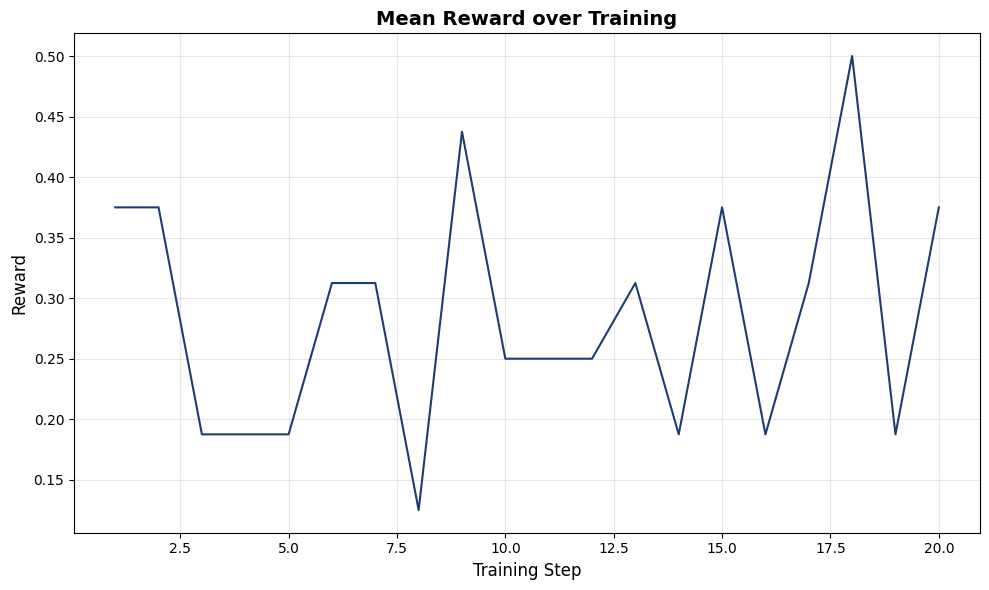

Saved reward_mean.png


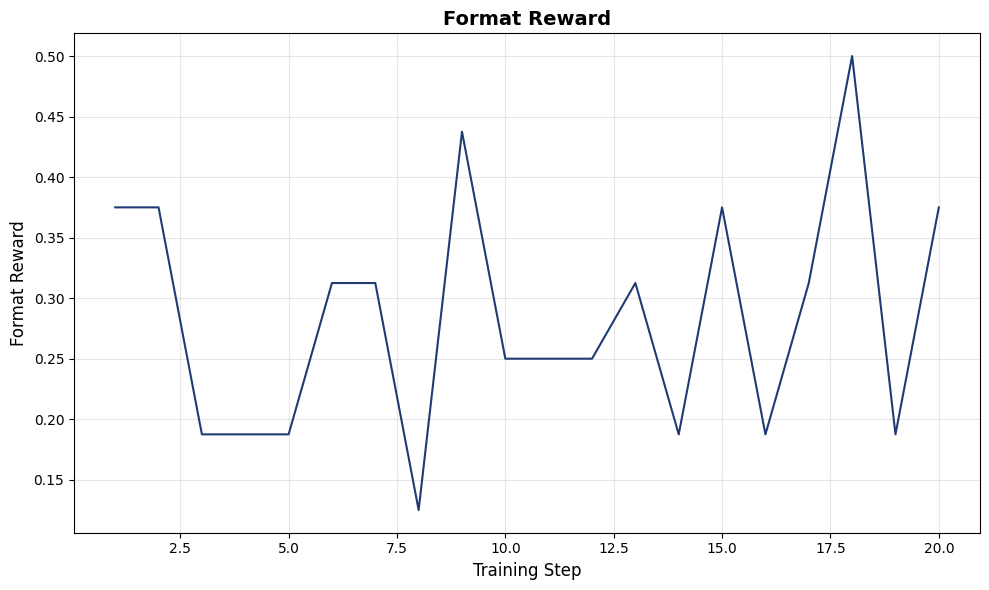

Saved reward_format.png


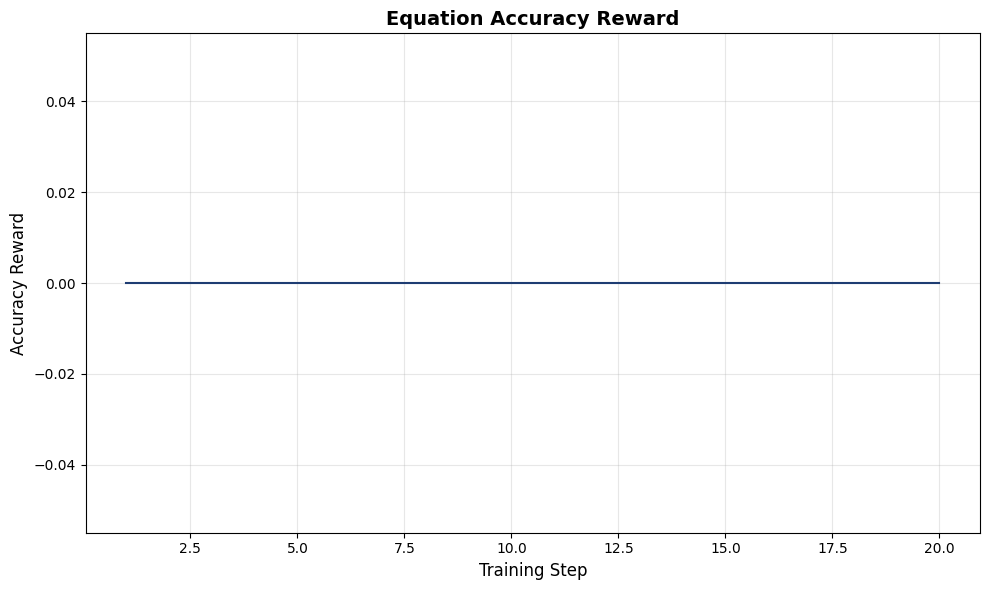

Saved reward_accuracy.png


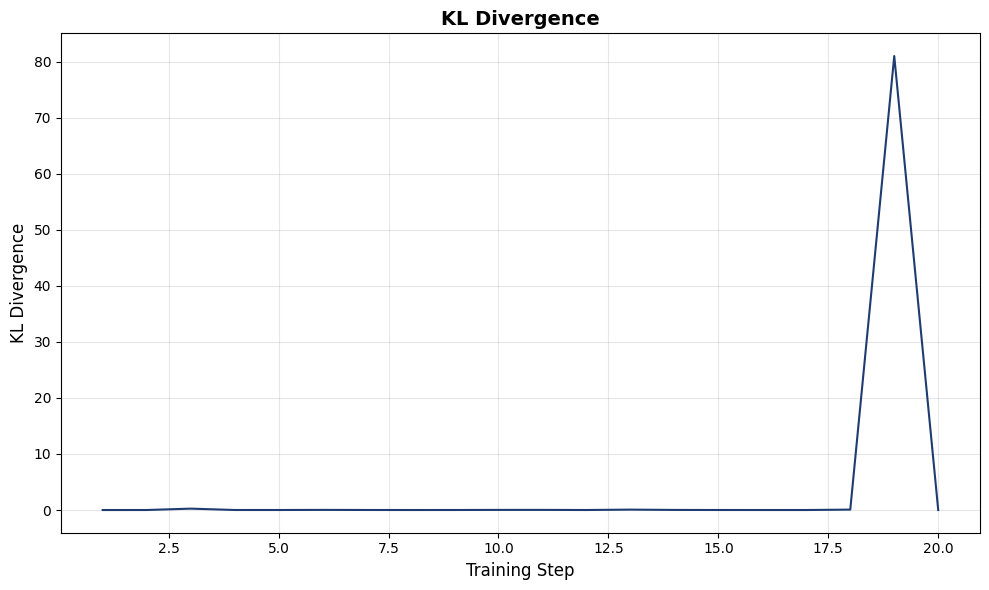

Saved kl_divergence.png


In [ ]:
# Cell 8: Save Model and Plot Results
!pip install matplotlib
!pip install tensorboard
import os
import glob
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Save the fine-tuned model
trainer.save_model("deepseek-r1-aha-countdown/final")
print("Model saved to deepseek-r1-aha-countdown/final")

# Find the TensorBoard event file
log_dir = "deepseek-r1-aha-countdown"
event_files = glob.glob(os.path.join(log_dir, "**", "events.out.tfevents.*"), recursive=True)
if not event_files:
    raise FileNotFoundError(f"No TensorBoard event files found in {log_dir}")

event_file_dir = os.path.dirname(event_files[0])
print(f"Reading TensorBoard events from: {event_file_dir}")

# Load the event accumulator
ea = EventAccumulator(event_file_dir)
ea.Reload()

# Print available scalar tags
available_tags = ea.Tags()["scalars"]
print(f"Available tags: {available_tags}")


def plot_metric(ea, tag, title, ylabel, filename):
    """Plot a single TensorBoard scalar metric."""
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]

    plt.figure(figsize=(10, 6))
    plt.plot(steps, values, linewidth=1.5, color="#1e3c72")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Training Step", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# Define metrics to plot
metrics = [
    ("train/reward", "Mean Reward over Training", "Reward", "reward_mean.png"),
    ("train/rewards/format_reward_func", "Format Reward", "Format Reward", "reward_format.png"),
    ("train/rewards/equation_reward_func", "Equation Accuracy Reward", "Accuracy Reward", "reward_accuracy.png"),
    ("train/kl", "KL Divergence", "KL Divergence", "kl_divergence.png"),
]
for tag, title, ylabel, fname in metrics:
    if tag in available_tags:
        plot_metric(ea, tag, title, ylabel, fname)
        print(f"Saved {fname}")
    else:
        print(f"Tag '{tag}' not found, skipping")